Coletando dados da página: https://openresults.run/evento/2025-maratona-internacional-de-joao-pessoa-2025/?modalidade=5KM&genero=M#resultado
Coletando dados da página: https://openresults.run/evento/2025-maratona-internacional-de-joao-pessoa-2025/?modalidade=5KM&genero=F#resultado

--- Análise de Desempenho ---
Dados salvos com sucesso em 'maratona_joao_pessoa_5km_resultados.json'.

Desempenho Masculino (5km):
  Total de corredores: 855
  Tempo médio: 0:33:21
  Tempo mais rápido: 0:15:36
----------------------------------------------------------------------
Desempenho Feminino (5km):
  Total de corredoras: 953
  Tempo médio: 0:37:30
  Tempo mais rápido: 0:20:51
----------------------------------------------------------------------

--- Gerando Gráfico de Desempenho ---


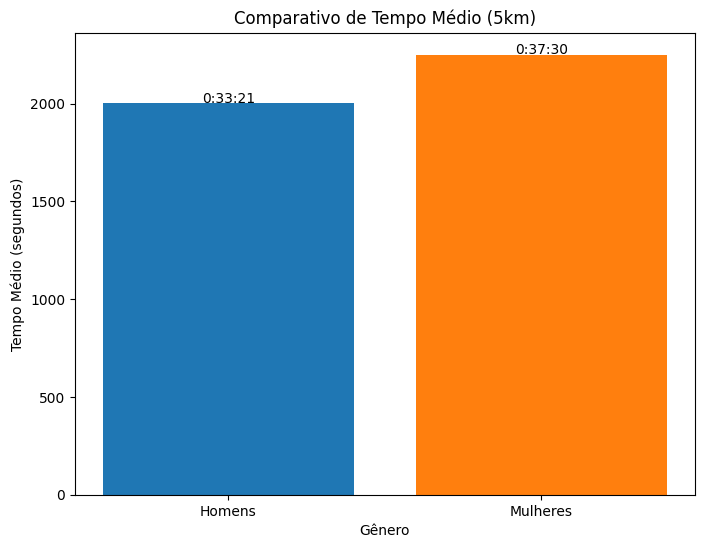

Em média, os homens foram 0:04:09 mais rápidos que as mulheres.


In [1]:
import requests
from bs4 import BeautifulSoup
import json
import pandas as pd
from datetime import timedelta
import re
import matplotlib.pyplot as plt

# URLs das corridas de 5km, separadas por gênero
urls = {
    "feminino": "https://openresults.run/evento/2025-maratona-internacional-de-joao-pessoa-2025/?modalidade=5KM&genero=F#resultado",
    "masculino": "https://openresults.run/evento/2025-maratona-internacional-de-joao-pessoa-2025/?modalidade=5KM&genero=M#resultado"
}

def parse_time_to_seconds(time_str):
    """Converte uma string de tempo (HH:MM:SS) em segundos."""
    try:
        h, m, s = map(int, time_str.split(':'))
        return timedelta(hours=h, minutes=m, seconds=s).total_seconds()
    except (ValueError, AttributeError):
        return None

def scrape_results_by_url(url):
    """
    Faz a requisição para uma URL e extrai todos os resultados de uma tabela.
    """
    try:
        print(f"Coletando dados da página: {url}")
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        html_content = response.text
    except requests.exceptions.RequestException as e:
        print(f"Erro ao acessar a URL {url}: {e}")
        return []

    soup = BeautifulSoup(html_content, 'html.parser')
    results_table = soup.find('table', {'id': 'tableResultados'})
    
    if not results_table:
        print(f"Aviso: Nenhuma tabela de resultados válida foi encontrada na URL {url}.")
        return []

    results = []
    headers = [th.get_text(strip=True) for th in results_table.find('thead').find_all('th')]
    
    header_map = {
        'Pos.': 'Posicao', 'Nº': 'Numero', 'Nome': 'Nome', 'Equipe': 'Equipe', 
        'Cat.': 'Categoria', 'Pace': 'Ritmo', 'Tempo': 'Tempo', 'Dif.': 'Diferenca'
    }

    for row in results_table.find('tbody').find_all('tr'):
        cells = row.find_all('td')
        if len(cells) == len(headers):
            runner_data = {header_map.get(headers[i], headers[i]): cell.get_text(strip=True) for i, cell in enumerate(cells)}
            results.append(runner_data)
    
    return results

# Extrai os resultados para cada gênero
male_results = scrape_results_by_url(urls["masculino"])
female_results = scrape_results_by_url(urls["feminino"])

if not male_results and not female_results:
    print("Nenhum resultado foi extraído. O script será encerrado.")
    exit()

# --- Análise de Desempenho e Salvamento dos Dados ---
print("\n--- Análise de Desempenho ---")

all_data = {
    "masculino": male_results,
    "feminino": female_results
}

file_name = "maratona_joao_pessoa_5km_resultados.json"
with open(file_name, 'w', encoding='utf-8') as f:
    json.dump(all_data, f, ensure_ascii=False, indent=4)
print(f"Dados salvos com sucesso em '{file_name}'.")

# Converte os resultados para DataFrames para análise
df_male = pd.DataFrame(male_results)
df_female = pd.DataFrame(female_results)

if not df_male.empty:
    df_male['Tempo_em_segundos'] = df_male['Tempo'].apply(parse_time_to_seconds)
    avg_male_time = df_male['Tempo_em_segundos'].mean()
    fastest_male_time = df_male['Tempo_em_segundos'].min()
    print(f"\nDesempenho Masculino (5km):")
    print(f"  Total de corredores: {len(df_male)}")
    print(f"  Tempo médio: {str(timedelta(seconds=int(avg_male_time)))}")
    print(f"  Tempo mais rápido: {str(timedelta(seconds=int(fastest_male_time)))}")
else:
    print("Nenhum dado de desempenho masculino encontrado.")

print("-" * 70)

if not df_female.empty:
    df_female['Tempo_em_segundos'] = df_female['Tempo'].apply(parse_time_to_seconds)
    avg_female_time = df_female['Tempo_em_segundos'].mean()
    fastest_female_time = df_female['Tempo_em_segundos'].min()
    print(f"Desempenho Feminino (5km):")
    print(f"  Total de corredoras: {len(df_female)}")
    print(f"  Tempo médio: {str(timedelta(seconds=int(avg_female_time)))}")
    print(f"  Tempo mais rápido: {str(timedelta(seconds=int(fastest_female_time)))}")
else:
    print("Nenhum dado de desempenho feminino encontrado.")

print("-" * 70)

# --- Gerando o Gráfico de Desempenho ---
print("\n--- Gerando Gráfico de Desempenho ---")

if not df_male.empty and not df_female.empty:
    # Prepara os dados para o gráfico
    generos = ['Homens', 'Mulheres']
    tempos_medios = [avg_male_time, avg_female_time]

    # Cria o gráfico de barras
    plt.figure(figsize=(8, 6))
    plt.bar(generos, tempos_medios, color=['#1f77b4', '#ff7f0e'])
    
    # Adiciona rótulos e título
    plt.xlabel('Gênero')
    plt.ylabel('Tempo Médio (segundos)')
    plt.title('Comparativo de Tempo Médio (5km)')
    
    # Adiciona o valor exato em cima de cada barra
    for i, v in enumerate(tempos_medios):
        # Converte segundos para o formato HH:MM:SS para mostrar no gráfico
        tempo_str = str(timedelta(seconds=int(v)))
        plt.text(i, v + 5, tempo_str, ha='center')

    plt.show()
else:
    print("Não há dados suficientes para gerar o gráfico de comparação.")

if not df_male.empty and not df_female.empty:
    if avg_male_time < avg_female_time:
        print(f"Em média, os homens foram {str(timedelta(seconds=int(avg_female_time - avg_male_time)))} mais rápidos que as mulheres.")
    elif avg_female_time < avg_male_time:
        print(f"Em média, as mulheres foram {str(timedelta(seconds=int(avg_male_time - avg_female_time)))} mais rápidas que os homens.")
    else:
        print("A média de tempo entre homens e mulheres foi a mesma.")